# MCF7 Sweep


In [1]:
from pathlib import Path
import sys

def _find_repo_root() -> Path:
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'pyproject.toml').exists() and (path / 'src' / 'cytof_archetypes').exists():
            return path
    fallback = Path('/Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv')
    if (fallback / 'src' / 'cytof_archetypes').exists():
        return fallback
    raise RuntimeError('Could not locate repository root')

REPO_ROOT = _find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
print('Repo root:', REPO_ROOT)

Repo root: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv


In [2]:
import re
import numpy as np
import pandas as pd
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

# -- Data prep config -----------------------------------------------------
BREAST_DATA_DIR  = Path('/Users/ronguy/Dropbox/CyTOF_Breast/for_guy')
FILE_VARIANT     = 'normalized_not_scaled'
FILE_EXTENSION   = 'parquet'
SAMPLE_ID_REGEX  = r'_([0-9]+(?:\.[0-9]+)?)$'
EXCLUDE_DOT2     = True                   # skip .2 samples (replicates)
EXCLUDED_MARKERS = ['H3', 'H4', 'H3.3']  # backbone markers

# Downsampling -- applied AFTER VIM removal, equal cells per sample
TARGET_TOTAL_CELLS = 150_000
RANDOM_STATE       = 42

# Clipping
CLIP_MARKERS = True
CLIP_UPPER_PERCENTILE = 99.9

# VIM removal -- applied to ALL cells BEFORE downsampling
REMOVE_VIM_HIGH_COMPONENT = False
VIM_MARKER_CANDIDATES     = ['VIM', 'Vimentin']
VIM_MARKER_MATCH_MODE     = 'contains'
VIM_GMM_RANDOM_STATE      = 42
VIM_GMM_MAX_ITER          = 300

# Z-score -- equal-sample weighted, applied AFTER downsampling
APPLY_SAMPLE_WEIGHTED_ZSCORE = True
ZSCORE_WEIGHT_MODE           = 'equal_samples'
ZSCORE_EPS                   = 1e-8

OUTPUT_H5AD      = REPO_ROOT / 'data' / 'MCF7.h5ad'
FORCE_REGENERATE = True
# -------------------------------------------------------------------------



In [3]:
import anndata as ad
import uuid

adata = ad.read_h5ad(OUTPUT_H5AD)
needs_uuid = ('cell_uuid' not in adata.obs.columns) or adata.obs['cell_uuid'].astype(str).nunique() != adata.n_obs
if needs_uuid:
    adata.obs['cell_uuid'] = [str(uuid.uuid5(uuid.NAMESPACE_URL, f'MCF7::{obs_id}')) for obs_id in adata.obs_names.astype(str)]
    adata.write_h5ad(OUTPUT_H5AD)
adata

AnnData object with n_obs × n_vars = 20505 × 32
    obs: 'Line', 'cell_uuid'

In [4]:
import os
import time
from cytof_archetypes.experiments import load_suite_config, run_experiment_suite

CONFIG_PATH = REPO_ROOT / 'configs' / 'breast_pae_MCF7_k_sweep.yaml'
assert CONFIG_PATH.exists(), f'Missing config: {CONFIG_PATH}'

RUN_SWEEP = True   # set to False to skip and go straight to analysis

cfg = load_suite_config(CONFIG_PATH)
_env = os.environ.get('CYTOF_SUITE_OUTPUT_DIR')
if _env:
    cfg['output_dir'] = _env
cfg.setdefault('dataset', {})['cell_id_column'] = 'cell_uuid'

# Enable live loss plot
cfg['show_progress'] = True
cfg['show_run_logs'] = True
cfg['show_training_progress'] = True
pae_cfg = cfg.setdefault('methods', {}).setdefault('probabilistic_archetypal_ae', {})
pae_cfg['live_loss_plot'] = False  # tqdm status bar shows loss instead
pae_cfg['show_training_progress'] = True

print('Config:', CONFIG_PATH)
print('Output dir:', cfg['output_dir'])
print('K sweep:', cfg.get('sweeps', {}).get('k_values', []))
print('Seeds:', cfg.get('seeds', []))
print('Downsample factor:', cfg.get('dataset', {}).get('downsample_factor', 'none'))

if RUN_SWEEP:
    t0 = time.time()
    out_dir = run_experiment_suite(cfg)
    print(f'Sweep completed in {(time.time()-t0)/60:.1f} min  |  output: {out_dir}')
else:
    print('Sweep skipped (RUN_SWEEP=False). Using existing outputs.')

Config: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/configs/breast_pae_MCF7_k_sweep.yaml
Output dir: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/breast_pae_MCF_k_sweep
K sweep: [5]
Seeds: [42, 123, 456]
Downsample factor: none


Suite phases:   0%|          | 0/12 [00:00<?, ?phase/s]

[suite-phase] 1/12: prepare_data


[suite-phase] 2/12: run_core_benchmark (all methods × dims × seeds)


MPS/GPU benchmark runs:   0%|          | 0/3 [00:00<?, ?run/s]

...

[suite-phase] 9/12: run_secondary_dataset_validation


[suite-phase] 10/12: run_auxiliary_representation_models


[suite-phase] 11/12: run_interpretability_tradeoff


[suite-phase] 12/12: generate_benchmark_notebooks -> /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/notebooks/experiment_suite


Sweep completed in 1.4 min  |  output: /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/breast_pae_MCF_k_sweep


In [5]:
import os

# ── USER CONFIG ───────────────────────────────────────────────────────────────
OUTPUT_DIR    = REPO_ROOT / 'outputs' / 'breast_pae_MCF_k_sweep'
METHOD        = 'probabilistic_archetypal_ae'
K_VALUES      = None    # None = auto-discover from dim_* subdirectories
VAR_THRESH    = 1e5     # mean archetype variance above this = dead
ASSIGN_THRESH = 0.25    # max_weight threshold for 'assigned' cell
# ─────────────────────────────────────────────────────────────────────────────


RUNS_DIR = OUTPUT_DIR / 'runs' / METHOD
if not RUNS_DIR.exists():
    print(f'Runs directory not found: {RUNS_DIR}')
    print('Run the sweep first (Step 2 above).')
else:
    if K_VALUES is None:
        K_VALUES = sorted([
            int(p.name.split('_')[1])
            for p in RUNS_DIR.iterdir()
            if p.is_dir() and p.name.startswith('dim_') and p.name.split('_')[1].isdigit()
        ])
    print(f'Output dir:  {OUTPUT_DIR}')
    print(f'K values:    {K_VALUES}')

Output dir:  /Users/ronguy/Dropbox/Work/CyTOF/Experiments/ProbAE_Deconv/outputs/breast_pae_MCF_k_sweep
K values:    [4, 5, 6, 7]


In [6]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
from itertools import combinations


def _load_run(k, seed):
    # find the actual directory regardless of zero-padding (dim_4 vs dim_04)
    dim_matches = [p for p in RUNS_DIR.iterdir()
                   if p.is_dir() and p.name.startswith('dim_')
                   and p.name.split('_')[-1].isdigit()
                   and int(p.name.split('_')[-1]) == k]
    if not dim_matches: return None
    run_dir = dim_matches[0] / f'seed_{seed}'
    required = [run_dir/'component_means.csv', run_dir/'component_vars.csv', run_dir/'training_history.csv']
    weight_paths = [run_dir/'val'/'weights.csv', run_dir/'test'/'weights.csv', run_dir/'train'/'weights.csv']
    if not all(p.exists() for p in required): return None
    if not any(p.exists() for p in weight_paths): return None
    means = pd.read_csv(run_dir/'component_means.csv', index_col=0)
    cvars = pd.read_csv(run_dir/'component_vars.csv', index_col=0)
    hist  = pd.read_csv(run_dir/'training_history.csv')
    wframes = []
    for p in weight_paths:
        if p.exists():
            df = pd.read_csv(p, index_col=0)
            wframes.append(df[[c for c in df.columns if c.startswith('w_')]])
    W = pd.concat(wframes).values.astype('float32')
    return dict(k=k, seed=seed, means=means, cvars=cvars, hist=hist, W=W)


def _compute_metrics(run):
    k, means, cvars, hist, W = run['k'], run['means'], run['cvars'], run['hist'], run['W']
    best_val_loss = hist['val_loss'].min()
    n_epochs      = len(hist)
    mean_var      = cvars.mean(axis=1).values
    n_active      = int((mean_var < VAR_THRESH).sum())
    W_safe        = np.clip(W, 1e-9, 1.0)
    entropy       = -(W_safe * np.log(W_safe)).sum(axis=1)
    effective_k   = float(np.exp(entropy.mean()))
    M             = means.values
    diffs         = [np.linalg.norm(M[i]-M[j]) for i,j in combinations(range(k),2)] if k>1 else [0.]
    return dict(k=k, seed=run['seed'],
                best_val_loss=best_val_loss, n_epochs=n_epochs,
                n_active=n_active, active_frac=n_active/k,
                effective_k=effective_k, effective_k_frac=effective_k/k,
                diversity=float(np.mean(diffs)),
                assign_frac=float((W.max(axis=1)>=ASSIGN_THRESH).mean()),
                mean_entropy=entropy.mean())


def _cross_seed_stability(runs_k):
    if len(runs_k) < 2: return float('nan')
    sims = []
    for r1, r2 in combinations(runs_k, 2):
        M1 = r1['means'].values; M2 = r2['means'].values
        n1 = M1 / (np.linalg.norm(M1, axis=1, keepdims=True)+1e-9)
        n2 = M2 / (np.linalg.norm(M2, axis=1, keepdims=True)+1e-9)
        C  = n1 @ n2.T
        ri, ci = linear_sum_assignment(1-C)
        sims.append(float(C[ri,ci].mean()))
    return float(np.mean(sims))


all_runs, all_metrics = {}, []
for k in K_VALUES:
    dim_matches = [p for p in RUNS_DIR.iterdir()
                   if p.is_dir() and p.name.startswith('dim_')
                   and p.name.split('_')[-1].isdigit()
                   and int(p.name.split('_')[-1]) == k]
    if not dim_matches: print(f'  K={k}: not found, skipping'); continue
    dim_dir = dim_matches[0]
    runs_k = []
    for sd in sorted(p for p in dim_dir.iterdir() if p.is_dir() and p.name.startswith('seed_')):
        run = _load_run(k, int(sd.name.split('_')[1]))
        if run is None: print(f'  K={k} {sd.name}: incomplete'); continue
        runs_k.append(run); all_metrics.append(_compute_metrics(run))
    all_runs[k] = runs_k
    print(f'  K={k}: {len(runs_k)} seed(s) loaded')

metrics_df = pd.DataFrame(all_metrics)
print(f'\nTotal runs: {len(metrics_df)}')
display(metrics_df.round(4))

  K=4: 3 seed(s) loaded
  K=5: 3 seed(s) loaded
  K=6: 3 seed(s) loaded


  K=7: 3 seed(s) loaded

Total runs: 12


,k,seed,best_val_loss,n_epochs,n_active,active_frac,effective_k,effective_k_frac,diversity,assign_frac,mean_entropy
0,4,123,24.7631,2247,4,1.0,2.9708,0.7427,14.6446,1.0000,1.0888
1,4,42,24.9990,2170,4,1.0,2.8069,0.7017,13.8694,1.0000,1.0321
2,4,456,24.9730,2100,4,1.0,2.9243,0.7311,14.0016,1.0000,1.0730
3,5,123,22.5745,2321,5,1.0,3.3816,0.6763,14.0805,0.9993,1.2184
4,5,42,22.2532,2357,5,1.0,3.5310,0.7062,14.4898,0.9986,1.2616
5,5,456,22.0273,2613,5,1.0,3.5480,0.7096,14.7542,0.9985,1.2664
6,6,123,22.9735,2175,6,1.0,3.3860,0.5643,12.3943,0.9989,1.2197
7,6,42,19.7867,3058,6,1.0,4.3457,0.7243,17.1030,0.9635,1.4692
8,6,456,22.8276,2170,6,1.0,3.6017,0.6003,12.4183,0.9979,1.2814
9,7,123,19.2579,2653,7,1.0,4.3404,0.6201,14.4152,0.9704,1.4680


In [7]:
stability    = {k: _cross_seed_stability(runs) for k, runs in all_runs.items()}
stability_df = pd.DataFrame([{'k':k,'cross_seed_stability':v} for k,v in stability.items()])

agg = metrics_df.groupby('k').agg(
    best_val_loss_mean=('best_val_loss','mean'), best_val_loss_std=('best_val_loss','std'),
    active_frac_mean=('active_frac','mean'), effective_k_mean=('effective_k','mean'),
    effective_k_frac_mean=('effective_k_frac','mean'), diversity_mean=('diversity','mean'),
    assign_frac_mean=('assign_frac','mean'), n_seeds=('seed','count'),
).reset_index().merge(stability_df, on='k', how='left')

print('Per-K summary:')
display(agg.round(4))

Per-K summary:


,k,best_val_loss_mean,best_val_loss_std,active_frac_mean,effective_k_mean,effective_k_frac_mean,diversity_mean,assign_frac_mean,n_seeds,cross_seed_stability
0,4,24.9117,0.1293,1.0,2.9007,0.7252,14.1718,1.0000,3,0.9260
1,5,22.2850,0.2750,1.0,3.4869,0.6974,14.4415,0.9988,3,0.9489
2,6,21.8626,1.7993,1.0,3.7778,0.6296,13.9719,0.9868,3,0.7389
3,7,21.3264,2.1662,1.0,3.8464,0.5495,12.6358,0.9851,3,0.6627


## Diagnostic Plots

| Panel | What to look for |
|---|---|
| Val loss | Elbow — marginal gain flattens |
| Active fraction | Should stay 1.0; drop = collapse |
| Effective K | Should track K; plateau = redundant archetypes |
| Diversity | Drop = new archetypes become near-duplicates |
| Cross-seed stability | High = robust; low = different random basins |
| Assignment concentration | Fraction of cells with a dominant archetype |

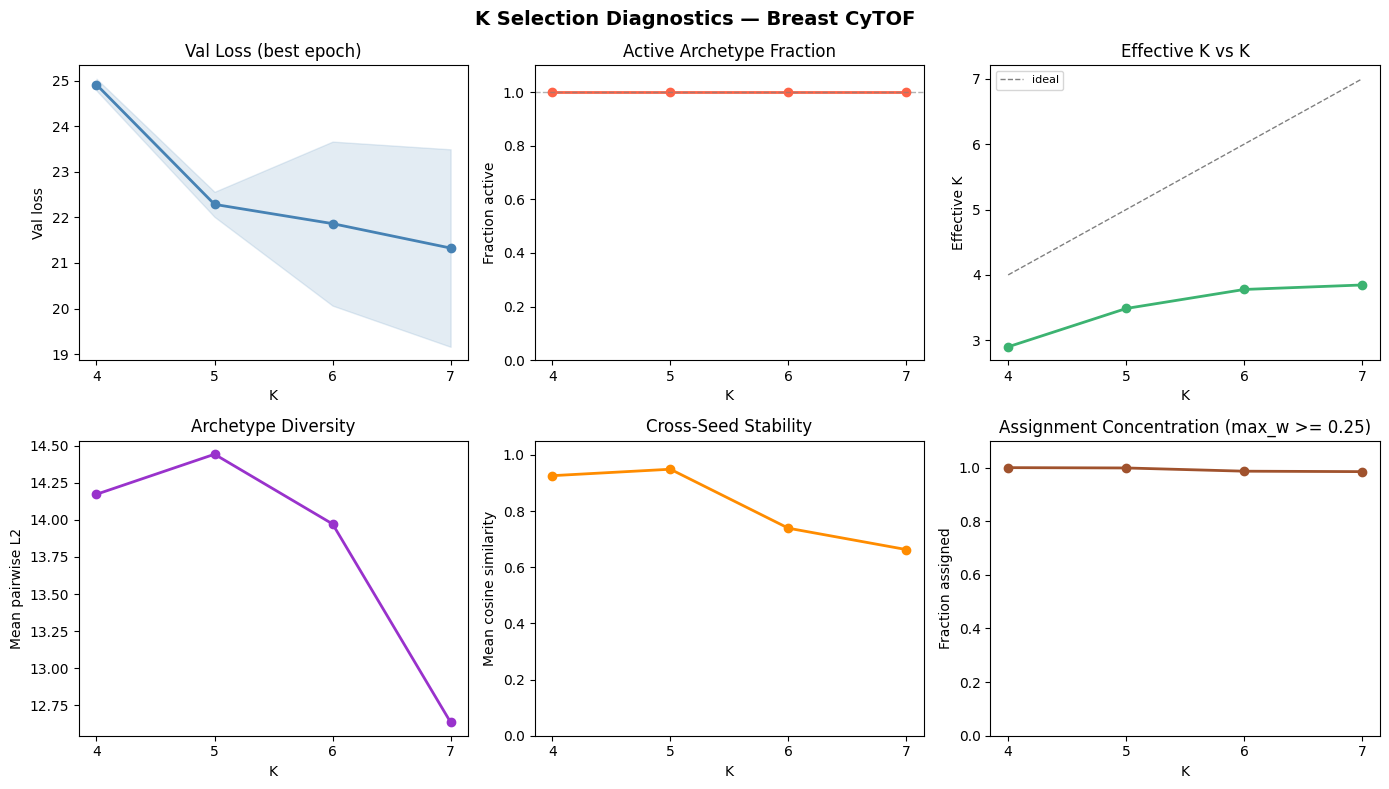

In [8]:
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

ks  = agg['k'].values
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('K Selection Diagnostics — Breast CyTOF', fontsize=14, fontweight='bold')

def _plot(ax, col, col_std=None, color='steelblue', ylabel='', title=''):
    y = agg[col].values
    ax.plot(ks, y, 'o-', color=color, linewidth=2, markersize=6)
    if col_std and col_std in agg.columns:
        e = agg[col_std].fillna(0).values
        ax.fill_between(ks, y-e, y+e, color=color, alpha=0.15)
    ax.set_title(title); ax.set_xlabel('K'); ax.set_ylabel(ylabel)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

_plot(axes[0,0],'best_val_loss_mean','best_val_loss_std','steelblue','Val loss','Val Loss (best epoch)')
_plot(axes[0,1],'active_frac_mean',color='tomato',ylabel='Fraction active',title='Active Archetype Fraction')
axes[0,1].axhline(1.0,color='gray',linestyle='--',linewidth=1,alpha=0.6); axes[0,1].set_ylim(0,1.1)
axes[0,2].plot(ks,ks,'--',color='gray',linewidth=1,label='ideal')
_plot(axes[0,2],'effective_k_mean',color='mediumseagreen',ylabel='Effective K',title='Effective K vs K')
axes[0,2].legend(fontsize=8)
_plot(axes[1,0],'diversity_mean',color='darkorchid',ylabel='Mean pairwise L2',title='Archetype Diversity')
ax=axes[1,1]
if agg['cross_seed_stability'].notna().any():
    ax.plot(ks,agg['cross_seed_stability'].values,'o-',color='darkorange',linewidth=2,markersize=6)
    ax.set_ylim(0,1.05); ax.set_ylabel('Mean cosine similarity')
else:
    ax.text(0.5,0.5,'Only 1 seed per K\n(add more seeds for\nstability estimate)',
            ha='center',va='center',transform=ax.transAxes,fontsize=10,color='gray')
ax.set_title('Cross-Seed Stability'); ax.set_xlabel('K')
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
_plot(axes[1,2],'assign_frac_mean',color='sienna',ylabel='Fraction assigned',
      title=f'Assignment Concentration (max_w >= {ASSIGN_THRESH})')
axes[1,2].set_ylim(0,1.1)
fig.tight_layout(); plt.show()

## Automated Recommendation

In [9]:
import warnings
import numpy as np

rec = agg.copy().sort_values('k').reset_index(drop=True)

# ── 1. Marginal loss improvement (elbow-based) ────────────────────────────────
# Instead of rewarding raw loss (monotonically improves with K), reward the
# *marginal gain* of each extra archetype. Score decays toward 0 as the curve
# flattens.  K values past the elbow get near-zero loss score.
losses = rec['best_val_loss_mean'].values.astype(float)
ks     = rec['k'].values.astype(float)

# Marginal improvement per unit K: -(Δloss / Δk), normalised to [0,1]
if len(losses) > 1:
    # Forward differences, pad last entry with 0
    dloss = -np.diff(losses, prepend=losses[0])   # positive = improvement
    dk    = np.diff(ks,     prepend=ks[0])
    dk[dk == 0] = 1
    marginal = np.maximum(dloss / dk, 0)
    marginal_norm = marginal / (marginal.max() + 1e-12)
else:
    marginal_norm = np.ones(len(losses))

rec['score_loss'] = marginal_norm  # high only where adding archetypes still helps

# ── 2. Absolute active archetype count (normalised) ──────────────────────────
# active_frac penalises large K too harshly by proportion.
# Instead reward the *absolute number* of active archetypes; normalise by max.
n_active = rec['active_frac_mean'] * rec['k']   # absolute count
rec['score_active'] = (n_active / (n_active.max() + 1e-12)).clip(0, 1)

# ── 3. Effective K fraction (unchanged) ──────────────────────────────────────
rec['score_eff_k'] = rec['effective_k_frac_mean'].clip(0, 1)

# ── 4. Cross-seed stability (unchanged) ──────────────────────────────────────
rec['score_stability'] = rec['cross_seed_stability'].fillna(0.5).clip(0, 1)

# ── 5. Dead-archetype multiplicative penalty ─────────────────────────────────
# Hard-penalise any K where more than 30% of archetypes are dead.
DEAD_FRAC_LIMIT = 0.30
dead_penalty = np.where(rec['active_frac_mean'] < (1 - DEAD_FRAC_LIMIT),
                        rec['active_frac_mean'] / (1 - DEAD_FRAC_LIMIT),
                        1.0)

# ── 6. Composite score ───────────────────────────────────────────────────────
rec['composite_score'] = (
    (0.30 * rec['score_loss']
   + 0.35 * rec['score_active']
   + 0.25 * rec['score_eff_k']
   + 0.10 * rec['score_stability'])
   * dead_penalty
)

display(rec[['k', 'best_val_loss_mean', 'active_frac_mean', 'effective_k_frac_mean',
             'cross_seed_stability', 'score_loss', 'score_active',
             'composite_score']].sort_values('composite_score', ascending=False).round(4))

best_k = int(rec.loc[rec['composite_score'].idxmax(), 'k'])
print(f'\n>>> Recommended K: {best_k} <<<')

br = rec[rec['k'] == best_k].iloc[0]
n_dead = round((1 - br['active_frac_mean']) * best_k)
if n_dead > 0:
    warnings.warn(f'K={best_k} has ~{n_dead} dead archetype(s) ({1-br["active_frac_mean"]:.0%}).')
if br['effective_k_frac_mean'] < 0.5:
    warnings.warn(f'K={best_k} effective utilisation low ({br["effective_k_frac_mean"]:.1%}).')


,k,best_val_loss_mean,active_frac_mean,effective_k_frac_mean,cross_seed_stability,score_loss,score_active,composite_score
1,5,22.2850,1.0,0.6974,0.9489,1.0000,0.7143,0.8192
3,7,21.3264,1.0,0.5495,0.6627,0.2041,1.0000,0.6149
2,6,21.8626,1.0,0.6296,0.7389,0.1608,0.8571,0.5795
0,4,24.9117,1.0,0.7252,0.9260,0.0000,0.5714,0.4739



>>> Recommended K: 5 <<<


## Per-Archetype Inspection — Recommended K

For the breast dataset, archetypes reflect cell states (luminal/basal subtypes,
mesenchymal/EMT, immune, cycling) rather than named cell types.

In [10]:
best_k=5
best_runs = all_runs.get(best_k, [])
if not best_runs:
    print(f'No runs for K={best_k}')
else:
    r = best_runs[0]
    means, mean_vars = r['means'], r['cvars'].mean(axis=1)
    print(f'K={best_k}, seed={r["seed"]} — archetype profiles (z-score means)\n')
    print(f'{"Arch":<6} {"MeanVar":>10}  {"Status":<8}  Top 4 (+)  |  Bottom 2 (-)')
    print('-'*100)
    for comp in means.index:
        idx  = int(comp.split('_')[1])
        row  = means.loc[comp]
        mvar = mean_vars[comp]
        top4 = row.nlargest(4); bot2 = row.nsmallest(2)
        print(f'A{idx:02d}    {mvar:10.2f}  {"ACTIVE" if mvar<VAR_THRESH else "DEAD":<8}  '
              f'{", ".join(f"{m}={v:+.2f}" for m,v in top4.items()):<55}  '
              f'{", ".join(f"{m}={v:+.2f}" for m,v in bot2.items())}')

K=5, seed=123 — archetype profiles (z-score means)

Arch      MeanVar  Status    Top 4 (+)  |  Bottom 2 (-)
----------------------------------------------------------------------------------------------------
A00          1.97  ACTIVE    KRT5=+3.26, H3K9me3=+2.72, H3K9me2=+2.72, NSD1=+2.71     CD24=-2.08, H3S28p=-1.95
A01          0.53  ACTIVE    H3K27me3=+3.23, H3K27me2=+3.12, p53=+2.96, GATA3=+2.20   H3K64ac=-2.39, NSD1=-1.20
A02          1.88  ACTIVE    KRT8-18=+1.64, Vimentin=+1.03, KRT5=+0.97, H3K36me3=+0.40  H3K9me2=-3.62, H3K9me3=-3.34
A03          0.46  ACTIVE    H3K64ac=+2.90, H3K9ac=+2.55, KI67=+1.81, CD44=+1.75      Vimentin=-1.03, NSD1=-0.56
A04          0.33  ACTIVE    CD49f=+1.01, H3K36me3=+0.98, EpCAM=+0.82, CD24=+0.76     p53=-4.07, H3K27me2=-3.54


## Archetype Mean Heatmap — Recommended K

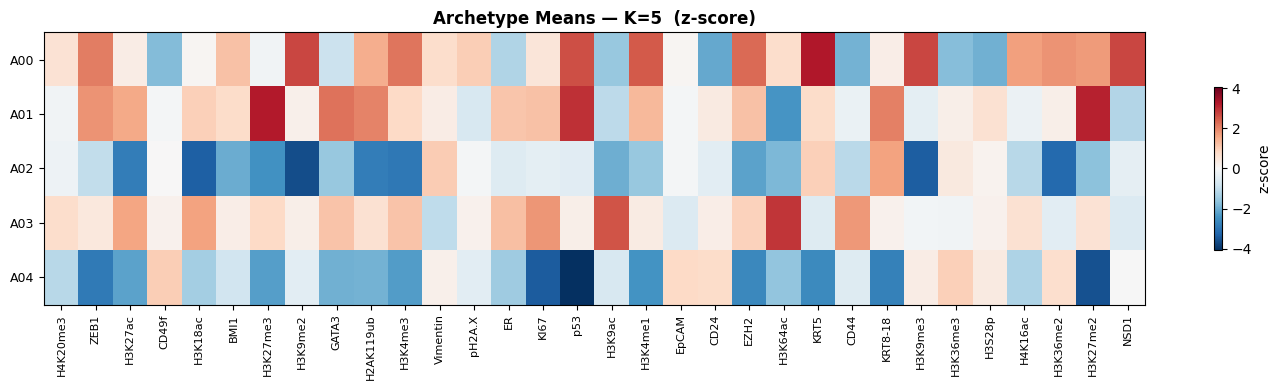

In [11]:
if best_runs:
    r = best_runs[0]
    means = r['means'].copy()
    means.index = [f'A{int(c.split("_")[1]):02d}' for c in means.index]
    vabs = max(abs(means.values.min()), abs(means.values.max()))
    fig, ax = plt.subplots(figsize=(max(10, len(means.columns)*0.45), max(4, best_k*0.5)))
    im = ax.imshow(means.values, aspect='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
    ax.set_xticks(range(len(means.columns)))
    ax.set_xticklabels(means.columns, rotation=90, fontsize=8)
    ax.set_yticks(range(best_k)); ax.set_yticklabels(means.index, fontsize=9)
    ax.set_title(f'Archetype Means — K={best_k}  (z-score)', fontweight='bold')
    plt.colorbar(im, ax=ax, shrink=0.6, label='z-score')
    fig.tight_layout(); plt.show()